In [1]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces

class TradingGymEnv(gym.Env):
    def __init__(self, df, state_features, transaction_cost=0.001):
        super().__init__()

        self.df = df.reset_index(drop=True).copy()
        self.state_features = state_features
        self.transaction_cost = transaction_cost
        self.n_steps = len(self.df)

        self.action_space = spaces.Discrete(3)  # 0 = HOLD, 1 = BUY, 2 = SELL
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(self.state_features),),
            dtype=np.float32
        )

        if "raw_return_1d" not in self.df.columns:
            raise ValueError("DataFrame must contain 'raw_return_1d' column for reward calculation.")

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_step = 0
        self.position = 0   # 0 = cash, 1 = long
        self.total_reward = 0.0
        self.portfolio_value = 1.0

        state = self._get_state()
        info = {}

        return state, info

    def _get_state(self):
        return self.df.loc[self.current_step, self.state_features].values.astype(np.float32)

    def step(self, action):
        reward = 0.0

        # stop before exceeding valid next-day return range
        if self.current_step >= self.n_steps - 2:
            terminated = True
            truncated = False
            next_state = np.zeros(len(self.state_features), dtype=np.float32)
            info = {
                "portfolio_value": self.portfolio_value,
                "position": self.position,
                "step": self.current_step
            }
            return next_state, reward, terminated, truncated, info

        # execute action at time t
        if action == 1:  # BUY
            if self.position == 0:
                self.position = 1
                reward -= self.transaction_cost

        elif action == 2:  # SELL
            if self.position == 1:
                self.position = 0
                reward -= self.transaction_cost

        # reward comes from next day's return, not today's return
        next_return = self.df.loc[self.current_step + 1, "raw_return_1d"]
        reward += self.position * next_return

        # reward clipping for PPO stability
        reward = float(np.clip(reward, -0.1, 0.1))

        # update portfolio
        self.total_reward += reward
        self.portfolio_value *= (1 + reward)

        # move to next step
        self.current_step += 1

        terminated = self.current_step >= self.n_steps - 2
        truncated = False

        next_state = (
            self._get_state()
            if not terminated
            else np.zeros(len(self.state_features), dtype=np.float32)
        )

        info = {
            "portfolio_value": self.portfolio_value,
            "position": self.position,
            "step": self.current_step
        }

        return next_state, reward, terminated, truncated, info

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df_all = pd.read_csv("global_trading_dataset.csv")

# Convert date
df_all["date"] = pd.to_datetime(df_all["date"])

# Sort by market and time
df_all = df_all.sort_values(["market", "date"]).reset_index(drop=True)

# Ensure numeric columns are float
numeric_cols = ["open", "high", "low", "close", "volume"]
df_all[numeric_cols] = df_all[numeric_cols].astype(float)

# Basic dataset info
print("Dataset shape:", df_all.shape)
print("Columns:", df_all.columns.tolist())

print("\nHead:")
print(df_all.head())

print("\nMarket distribution:")
print(df_all["market"].value_counts())

# Quick data quality check
print("\nNaN count:")
print(df_all.isna().sum())

print("\nInf count:")
print(np.isinf(df_all.select_dtypes(include=[float, int])).sum())

Dataset shape: (7361, 17)
Columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'market', 'return_1d', 'return_5d', 'return_10d', 'MA_5', 'MA_20', 'MA_gap', 'volatility_10', 'volume_change', 'RSI_14', 'MACD']

Head:
        date        close         high          low         open    volume  \
0 2020-02-06  2866.510010  2876.590088  2807.610107  2826.889893  316400.0   
1 2020-02-07  2875.959961  2875.959961  2838.770020  2858.929932  309500.0   
2 2020-02-10  2890.488037  2891.847900  2851.050049  2860.499023  294900.0   
3 2020-02-11  2901.669922  2913.820068  2882.239990  2894.540039  269200.0   
4 2020-02-12  2926.898926  2926.898926  2892.424072  2895.555908  248700.0   

  market  return_1d  return_5d  return_10d         MA_5        MA_20  \
0     CN   0.017183  -0.063463   -0.072339  2838.204004  3023.648462   
1     CN   0.003297  -0.033787   -0.064449  2818.090381  3013.186560   
2     CN   0.005052   0.052385   -0.060156  2846.866797  3003.521667   
3     CN   0.003869  

In [3]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class TradingGymEnv(gym.Env):
    def __init__(self, df, state_features, transaction_cost=0.001):
        super().__init__()

        self.df = df.reset_index(drop=True).copy()
        self.state_features = state_features
        self.transaction_cost = transaction_cost
        self.n_steps = len(self.df)

        # Action space: 0 = HOLD, 1 = BUY, 2 = SELL
        self.action_space = spaces.Discrete(3)

        # Observation space: state feature vector
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(self.state_features),),
            dtype=np.float32
        )

        # Reward must use raw next-day return
        if "raw_return_1d" not in self.df.columns:
            raise ValueError("DataFrame must contain 'raw_return_1d' column.")

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_step = 0
        self.position = 0   # 0 = cash, 1 = long
        self.total_reward = 0.0
        self.portfolio_value = 1.0

        state = self._get_state()
        info = {}

        return state, info

    def _get_state(self):
        return self.df.loc[self.current_step, self.state_features].values.astype(np.float32)

    def step(self, action):
        reward = 0.0

        # Stop before we run out of next-day return values
        if self.current_step >= self.n_steps - 2:
            terminated = True
            truncated = False
            next_state = np.zeros(len(self.state_features), dtype=np.float32)
            info = {
                "portfolio_value": self.portfolio_value,
                "position": self.position,
                "step": self.current_step
            }
            return next_state, reward, terminated, truncated, info

        # Execute action at time t
        if action == 1:  # BUY
            if self.position == 0:
                self.position = 1
                reward -= self.transaction_cost

        elif action == 2:  # SELL
            if self.position == 1:
                self.position = 0
                reward -= self.transaction_cost

        # Reward comes from next day's return, not today's return
        next_return = self.df.loc[self.current_step + 1, "raw_return_1d"]
        reward += self.position * next_return

        # Clip reward for PPO stability
        reward = float(np.clip(reward, -0.1, 0.1))

        # Update portfolio
        self.total_reward += reward
        self.portfolio_value *= (1 + reward)

        # Move to next step
        self.current_step += 1

        terminated = self.current_step >= self.n_steps - 2
        truncated = False

        next_state = (
            self._get_state()
            if not terminated
            else np.zeros(len(self.state_features), dtype=np.float32)
        )

        info = {
            "portfolio_value": self.portfolio_value,
            "position": self.position,
            "step": self.current_step
        }

        return next_state, reward, terminated, truncated, info

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler

state_features = [
    "return_1d",
    "return_5d",
    "return_10d",
    "MA_gap",
    "volatility_10",
    "volume_change",
    "RSI_14",
    "MACD"
]

# Work on a copy
df_rl = df_all.copy()

# Keep raw return for reward calculation before scaling
df_rl["raw_return_1d"] = df_rl["return_1d"]

# Replace inf with NaN
df_rl = df_rl.replace([np.inf, -np.inf], np.nan)

# Drop rows with missing values in features or reward column
df_rl = df_rl.dropna(subset=state_features + ["raw_return_1d"]).reset_index(drop=True)

# Use US market first for initial PPO testing
df_us_rl = df_rl[df_rl["market"] == "US"].sort_values("date").reset_index(drop=True).copy()

# Check data quality before scaling
print("NaN per feature before scaling:")
print(df_us_rl[state_features + ["raw_return_1d"]].isna().sum())

print("\nInf count before scaling:")
print(np.isinf(df_us_rl[state_features + ["raw_return_1d"]].select_dtypes(include=[float, int]).values).sum())

print("\nMax absolute values before scaling:")
print(np.abs(df_us_rl[state_features]).max())

# Standardize only state features
scaler = StandardScaler()
df_us_rl[state_features] = scaler.fit_transform(df_us_rl[state_features])

# Check data quality after scaling
print("\nNaN per feature after scaling:")
print(df_us_rl[state_features].isna().sum())

print("\nInf count after scaling:")
print(np.isinf(df_us_rl[state_features].values).sum())

print("\nScaled feature summary:")
print(df_us_rl[state_features].describe().T[["mean", "std", "min", "max"]])

# Create environment
env = TradingGymEnv(df_us_rl, state_features)

# Quick sanity check
obs, info = env.reset()
print("\nInitial state:", obs)
print("Reset info:", info)
print("Any NaN in obs:", np.isnan(obs).any())
print("Any Inf in obs:", np.isinf(obs).any())

# Random rollout test
done = False
while not done:
    action = np.random.choice([0, 1, 2])
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

print("\nFinal portfolio value:", info["portfolio_value"])
print("Total reward:", env.total_reward)

NaN per feature before scaling:
return_1d        0
return_5d        0
return_10d       0
MA_gap           0
volatility_10    0
volume_change    0
RSI_14           0
MACD             0
raw_return_1d    0
dtype: int64

Inf count before scaling:
0

Max absolute values before scaling:
return_1d          0.119841
return_5d          0.179666
return_10d         0.233863
MA_gap           409.470520
volatility_10      0.074826
volume_change      1.270527
RSI_14            96.234267
MACD             238.129990
dtype: float64

NaN per feature after scaling:
return_1d        0
return_5d        0
return_10d       0
MA_gap           0
volatility_10    0
volume_change    0
RSI_14           0
MACD             0
dtype: int64

Inf count after scaling:
0

Scaled feature summary:
                       mean       std       min       max
return_1d     -1.552968e-17  1.000336 -9.091966  7.140036
return_5d      0.000000e+00  1.000336 -6.865227  6.434968
return_10d    -9.556728e-18  1.000336 -6.545210  5.0535

In [5]:
import numpy as np

print("Checking RL dataset quality...")

# NaN check
print("\nNaN count per feature:")
print(df_us_rl[state_features].isna().sum())

# Inf check
print("\nInf count per feature:")
print(np.isinf(df_us_rl[state_features].values).sum())

# Extreme value check
print("\nMax absolute value per feature:")
print(np.abs(df_us_rl[state_features]).max())

# Feature statistics
print("\nFeature summary:")
print(df_us_rl[state_features].describe())

Checking RL dataset quality...

NaN count per feature:
return_1d        0
return_5d        0
return_10d       0
MA_gap           0
volatility_10    0
volume_change    0
RSI_14           0
MACD             0
dtype: int64

Inf count per feature:
0

Max absolute value per feature:
return_1d        9.091966
return_5d        6.865227
return_10d       6.545210
MA_gap           4.719998
volatility_10    7.936119
volume_change    6.672931
RSI_14           2.763667
MACD             5.014537
dtype: float64

Feature summary:
          return_1d    return_5d    return_10d       MA_gap  volatility_10  \
count  1.487000e+03  1487.000000  1.487000e+03  1487.000000   1.487000e+03   
mean  -1.552968e-17     0.000000 -9.556728e-18     0.000000   1.337942e-16   
std    1.000336e+00     1.000336  1.000336e+00     1.000336   1.000336e+00   
min   -9.091966e+00    -6.865227 -6.545210e+00    -4.719998  -9.778143e-01   
25%   -4.146766e-01    -0.438881 -4.395290e-01    -0.469644  -5.429356e-01   
50%    2.911

In [6]:
obs, info = env.reset()

print("Initial obs:", obs)
print("Obs shape:", obs.shape)
print("Obs dtype:", obs.dtype)

print("Any NaN in obs:", np.isnan(obs).any())
print("Any Inf in obs:", np.isinf(obs).any())

print("\nReset info:", info)

assert obs.shape == (len(state_features),), f"Unexpected observation shape: {obs.shape}"
assert not np.isnan(obs).any(), "Observation contains NaN"
assert not np.isinf(obs).any(), "Observation contains Inf"

print("\nEnvironment reset check passed.")

Initial obs: [ 0.19259557 -0.5817254  -0.20036043 -0.26831535 -0.37435344  0.20113195
 -0.27650607 -0.20978431]
Obs shape: (8,)
Obs dtype: float32
Any NaN in obs: False
Any Inf in obs: False

Reset info: {}

Environment reset check passed.


In [7]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

# Wrap environment for Stable-Baselines3
env = DummyVecEnv([lambda: Monitor(TradingGymEnv(df_us_rl, state_features))])

model = PPO(
    policy="MlpPolicy",
    env=env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.0,
    vf_coef=0.5,
    max_grad_norm=0.5,
    tensorboard_log="./ppo_trading_tensorboard/"
)

print("Starting PPO training...")

model.learn(
    total_timesteps=10000,
    progress_bar=True
)

print("Training finished.")

# Save model
model.save("ppo_trading_model")

Using cpu device
Starting PPO training...
Logging to ./ppo_trading_tensorboard/PPO_2


Output()

----------------------------
| time/              |     |
|    fps             | 848 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 256 |
----------------------------


------------------------------------------
| time/                   |              |
|    fps                  | 899          |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 0.0026224805 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | -1.48        |
|    learning_rate        | 0.0003       |
|    loss                 | -0.00602     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00747     |
|    value_loss           | 0.0369       |
------------------------------------------


-----------------------------------------
| time/                   |             |
|    fps                  | 959         |
|    iterations           | 3           |
|    time_elapsed         | 0           |
|    total_timesteps      | 768         |
| train/                  |             |
|    approx_kl            | 0.000842683 |
|    clip_fraction        | 0           |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.1        |
|    explained_variance   | -0.726      |
|    learning_rate        | 0.0003      |
|    loss                 | 0.000941    |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.0033     |
|    value_loss           | 0.00662     |
-----------------------------------------


...

----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 1.48e+03   |
|    ep_rew_mean          | 0.0944     |
| time/                   |            |
|    fps                  | 1496       |
|    iterations           | 37         |
|    time_elapsed         | 6          |
|    total_timesteps      | 9472       |
| train/                  |            |
|    approx_kl            | 0.00654776 |
|    clip_fraction        | 0.0379     |
|    clip_range           | 0.2        |
|    entropy_loss         | -0.763     |
|    explained_variance   | -0.854     |
|    learning_rate        | 0.0003     |
|    loss                 | -0.0238    |
|    n_updates            | 360        |
|    policy_gradient_loss | -0.00879   |
|    value_loss           | 0.000386   |
----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.48e+03    |
|    ep_rew_mean          | 0.0944      |
| time/                   |             |
|    fps                  | 1502        |
|    iterations           | 38          |
|    time_elapsed         | 6           |
|    total_timesteps      | 9728        |
| train/                  |             |
|    approx_kl            | 0.005106575 |
|    clip_fraction        | 0.0176      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.8        |
|    explained_variance   | -0.373      |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0174     |
|    n_updates            | 370         |
|    policy_gradient_loss | -0.00525    |
|    value_loss           | 0.000283    |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.48e+03    |
|    ep_rew_mean          | 0.0944      |
| time/                   |             |
|    fps                  | 1499        |
|    iterations           | 39          |
|    time_elapsed         | 6           |
|    total_timesteps      | 9984        |
| train/                  |             |
|    approx_kl            | 0.007983235 |
|    clip_fraction        | 0.0652      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.716      |
|    explained_variance   | 0.095       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0139     |
|    n_updates            | 380         |
|    policy_gradient_loss | -0.0118     |
|    value_loss           | 0.000761    |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.48e+03    |
|    ep_rew_mean          | 0.0944      |
| time/                   |             |
|    fps                  | 1503        |
|    iterations           | 40          |
|    time_elapsed         | 6           |
|    total_timesteps      | 10240       |
| train/                  |             |
|    approx_kl            | 0.009519761 |
|    clip_fraction        | 0.0715      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.716      |
|    explained_variance   | -0.369      |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0168     |
|    n_updates            | 390         |
|    policy_gradient_loss | -0.0161     |
|    value_loss           | 0.000282    |
-----------------------------------------


Training finished.


Final portfolio value: 2.213172424943713


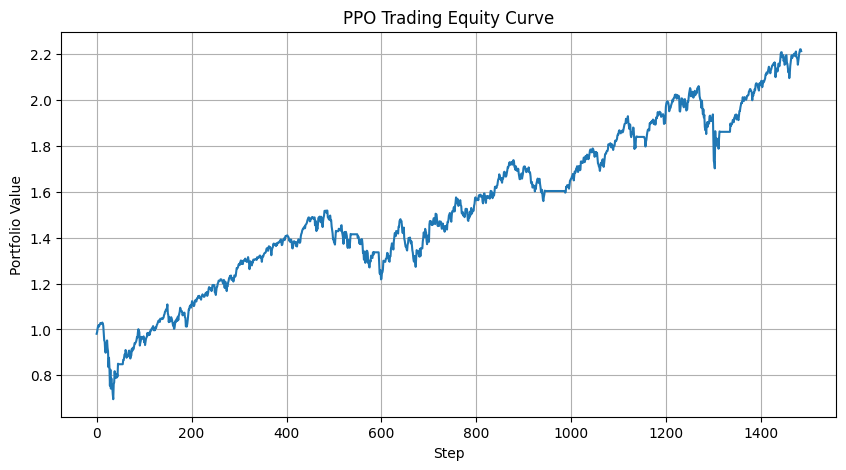

In [8]:
import matplotlib.pyplot as plt
import numpy as np

obs = env.reset()

portfolio_values = []
done = False

while not done:
    
    # PPO prediction
    action, _ = model.predict(obs, deterministic=True)
    
    obs, rewards, dones, infos = env.step(action)
    
    # VecEnv returns arrays
    done = dones[0]
    
    portfolio_value = infos[0]["portfolio_value"]
    portfolio_values.append(portfolio_value)

print("Final portfolio value:", portfolio_values[-1])

# Plot equity curve
plt.figure(figsize=(10,5))
plt.plot(portfolio_values)
plt.title("PPO Trading Equity Curve")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()

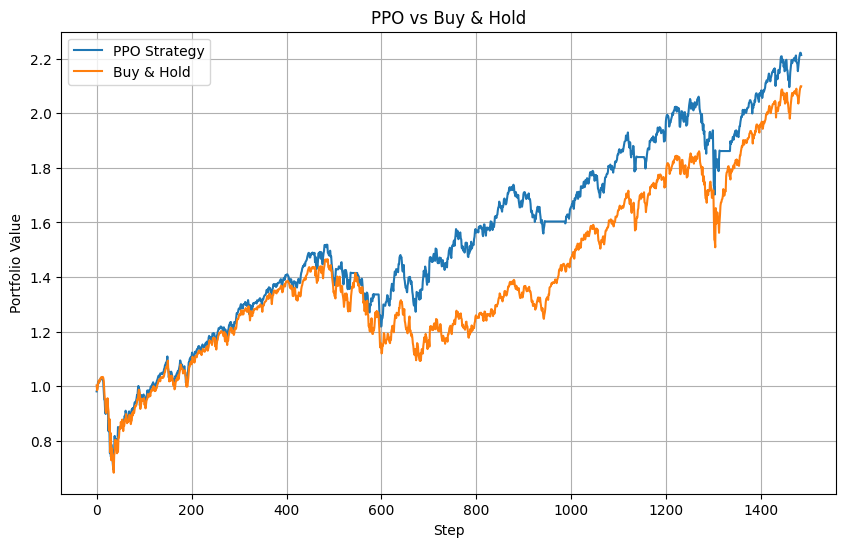

PPO final value: 2.213172424943713
Buy & Hold final value: 2.098667291897693


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Buy & Hold equity curve
returns = df_us_rl["raw_return_1d"].values

bh_portfolio = [1.0]

for r in returns:
    bh_portfolio.append(bh_portfolio[-1] * (1 + r))

bh_portfolio = bh_portfolio[1:]

# PPO curve already computed
ppo_curve = portfolio_values

# Plot comparison
plt.figure(figsize=(10,6))

plt.plot(ppo_curve, label="PPO Strategy")
plt.plot(bh_portfolio[:len(ppo_curve)], label="Buy & Hold")

plt.title("PPO vs Buy & Hold")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()

plt.show()

print("PPO final value:", ppo_curve[-1])
print("Buy & Hold final value:", bh_portfolio[len(ppo_curve)-1])